In [1]:
import mcmr

/home/azma/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [8]:
x_world, y_world = 50, 50
x_grid = [12, 23, 36]
y_grid = [14, 26, 38]

material_matrix = [
    ["Fe", "Pb", "C",  "Fe"],
    ["Pb", "Fe", "Pb", "C"],
    ["C",  "Pb", "Fe", "Pb"],
    ["Fe", "C",  "Pb", "Fe"],
]

sources = [
    [0, 1, 1, 0],
    [2, 1, 1, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
]

In [14]:
world = mcmr.World(
    x_world=x_world, y_world=y_world,
    x_grid=x_grid, y_grid=y_grid,
    material_matrix=material_matrix,
    sources=sources,
    bc_top="reflective",
    bc_bot="vacuum",
    bc_left="reflective",
    bc_right="vacuum",
)

In [15]:
sim = world.run(N=1000)

              MCMR Simulation Engine               
 Total Particle   : 1000
running...
Progress: [1000/1000] (100%)
 Simulation End in 3.4138 seconds.



In [16]:
t = sim.get_tally()
print(t.absorp_by_material)

{'C': 305, 'Fe': 384, 'Pb': 309}


In [17]:
world.export("mcmr_world.xml")

'mcmr_world.xml'

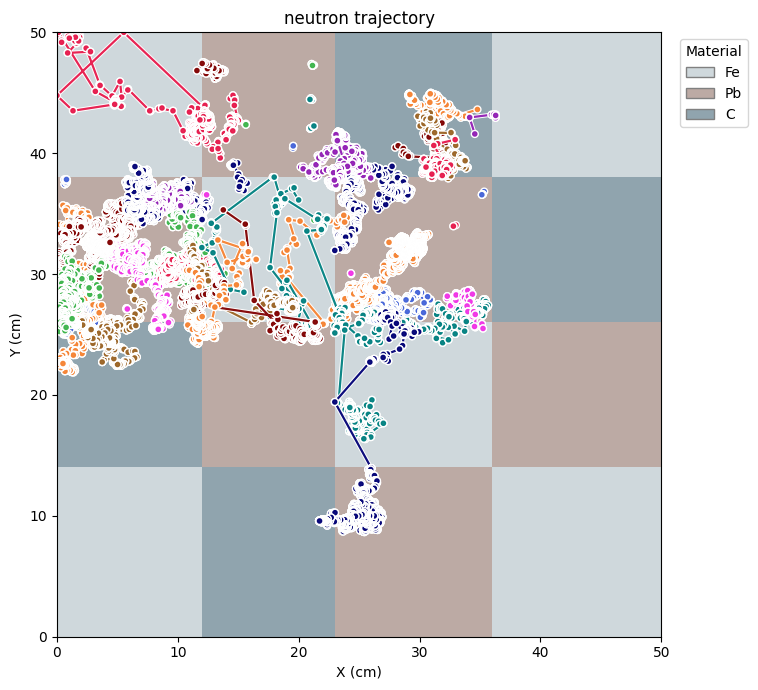

In [18]:
plotter = mcmr.ResultsPlotter("mcmr_results.xml")
plotter.plot_trajectories(world_xml="mcmr_world.xml")